In [3]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scipy

   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ------ --------------------------------- 6.0/37.4 MB 32.8 MB/s eta 0:00:01
   ------------------ --------------------- 17.0/37.4 MB 42.9 MB/s eta 0:00:01
   ------------------------ --------------- 22.5/37.4 MB 36.7 MB/s eta 0:00:01
   ---------------------------------- ----- 32.2/37.4 MB 38.9 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.4 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 34.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install warnings

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)
ERROR: No matching distribution found for warnings


In [1]:
"""
Mental Disorders Dataset - Comprehensive Analysis
Author: Data Analysis Script
Date: 2025
Description: Complete analysis pipeline for mental health symptoms and diagnoses dataset
"""

# ===========================
# 1. IMPORTS AND SETUP
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# ===========================
# 2. DATA LOADING AND INITIAL EXPLORATION
# ===========================
print("="*80)
print("MENTAL DISORDERS DATASET - COMPREHENSIVE ANALYSIS")
print("="*80)

# Load the dataset
df = pd.read_csv('mental_disorders_dataset.csv')

print("\n📊 BASIC DATASET INFORMATION")
print("-"*40)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)

print("\n📋 FIRST 5 ROWS OF DATA:")
print(df.head())

print("\n📈 STATISTICAL SUMMARY:")
print(df.describe(include='all'))

MENTAL DISORDERS DATASET - COMPREHENSIVE ANALYSIS

📊 BASIC DATASET INFORMATION
----------------------------------------
Dataset shape: 120 rows × 19 columns

Column names and types:
Patient Number         str
Sadness                str
Euphoric               str
Exhausted              str
Sleep dissorder        str
Mood Swing             str
Suicidal thoughts      str
Anorxia                str
Authority Respect      str
Try-Explanation        str
Aggressive Response    str
Ignore & Move-On       str
Nervous Break-down     str
Admit Mistakes         str
Overthinking           str
Sexual Activity        str
Concentration          str
Optimisim              str
Expert Diagnose        str
dtype: object

📋 FIRST 5 ROWS OF DATA:
  Patient Number    Sadness    Euphoric  Exhausted Sleep dissorder Mood Swing  \
0     Patiant-01    Usually      Seldom  Sometimes       Sometimes        YES   
1     Patiant-02    Usually      Seldom    Usually       Sometimes         NO   
2     Patiant-03  Somet

In [5]:
# ===========================
# 3. DATA QUALITY ASSESSMENT
# ===========================
print("\n"+"="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Check for missing values
print("\n🔍 Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_data[missing_data['Missing_Count'] > 0])
if missing_data['Missing_Count'].sum() == 0:
    print("✅ No missing values found in the dataset!")

# Check for duplicates
print(f"\n🔍 Duplicate Rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    print("⚠️ Duplicate rows found! Consider removing them.")

# Check unique values for each column
print("\n🔍 Unique Values per Column:")
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values")
    if unique_vals <= 10:  # Show values if there are 10 or fewer
        print(f"   Values: {df[col].unique()}")


DATA QUALITY ASSESSMENT

🔍 Missing Values Analysis:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []
✅ No missing values found in the dataset!

🔍 Duplicate Rows: 0

🔍 Unique Values per Column:
Patient Number: 120 unique values
Sadness: 4 unique values
   Values: <StringArray>
['Usually', 'Sometimes', 'Seldom', 'Most-Often']
Length: 4, dtype: str
Euphoric: 4 unique values
   Values: <StringArray>
['Seldom', 'Most-Often', 'Usually', 'Sometimes']
Length: 4, dtype: str
Exhausted: 4 unique values
   Values: <StringArray>
['Sometimes', 'Usually', 'Seldom', 'Most-Often']
Length: 4, dtype: str
Sleep dissorder: 4 unique values
   Values: <StringArray>
['Sometimes', 'Most-Often', 'Usually', 'Seldom']
Length: 4, dtype: str
Mood Swing: 2 unique values
   Values: <StringArray>
['YES', 'NO']
Length: 2, dtype: str
Suicidal thoughts: 3 unique values
   Values: <StringArray>
['YES ', 'YES', 'NO']
Length: 3, dtype: str
Anorxia: 2 unique values
   Values: <StringArray>
['NO

In [6]:
# ===========================
# 4. DATA PREPROCESSING
# ===========================
print("\n"+"="*80)
print("DATA PREPROCESSING")
print("="*80)

# Create a copy for processing
df_processed = df.copy()

# Identify symptom columns (excluding Patient Number and Expert Diagnose)
symptom_columns = [col for col in df.columns if col not in ['Patient Number', 'Expert Diagnose']]
print(f"\n📝 Identified {len(symptom_columns)} symptom columns")


DATA PREPROCESSING

📝 Identified 17 symptom columns



EXPLORATORY DATA ANALYSIS

🏥 Mental Disorder Distribution:
Expert Diagnose
Bipolar Type-2    31
Depression        31
Normal            30
Bipolar Type-1    28
Name: count, dtype: int64

Total unique diagnoses: 4

🔬 Symptom Prevalence Analysis:

Top 10 Most Common Symptoms:
1. Overthinking: 54.17%
2. Nervous Break-down: 51.67%
3. Admit Mistakes: 49.17%
4. Aggressive Response: 48.33%
5. Mood Swing: 47.50%
6. Try-Explanation: 47.50%
7. Suicidal thoughts: 46.67%
8. Ignore & Move-On: 41.67%
9. Authority Respect: 39.17%
10. Anorxia: 38.33%


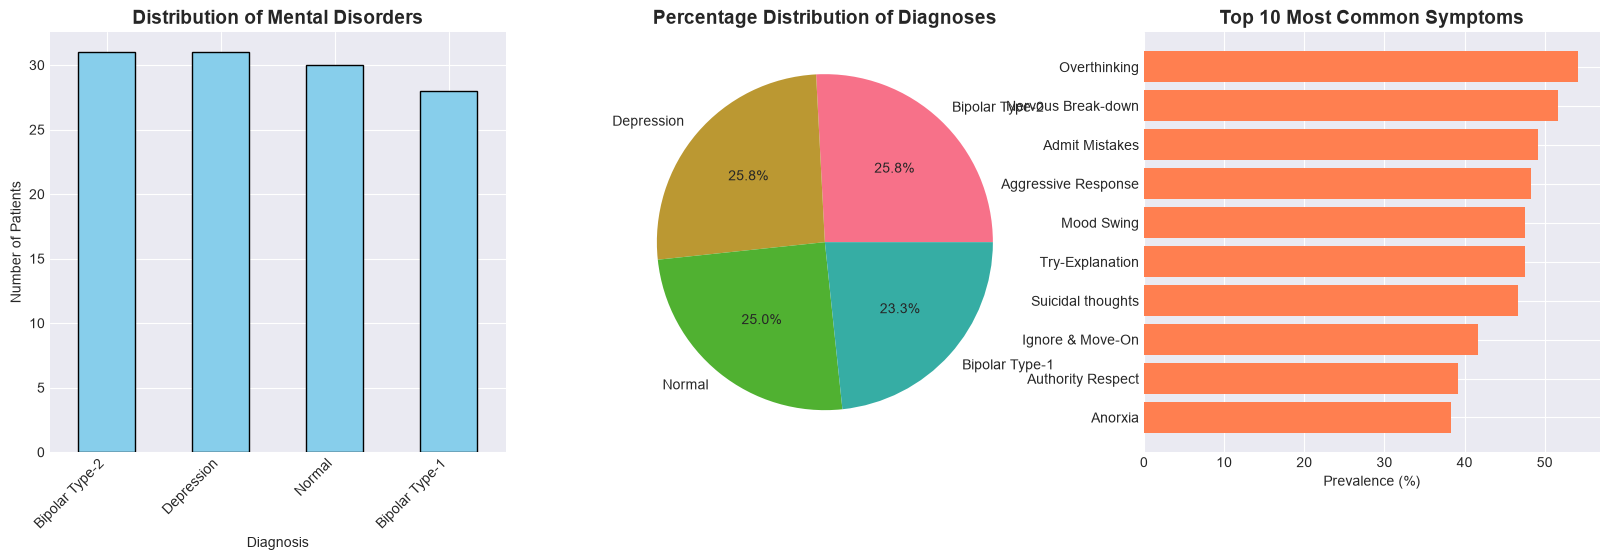

In [7]:
# ===========================
# 5. EXPLORATORY DATA ANALYSIS
# ===========================
print("\n"+"="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Analyze Expert Diagnose distribution
print("\n🏥 Mental Disorder Distribution:")
diagnosis_counts = df['Expert Diagnose'].value_counts()
print(diagnosis_counts)
print(f"\nTotal unique diagnoses: {df['Expert Diagnose'].nunique()}")

# Create visualizations
fig = plt.figure(figsize=(20, 12))

# Plot 1: Diagnosis Distribution
ax1 = plt.subplot(2, 3, 1)
diagnosis_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Mental Disorders', fontsize=14, fontweight='bold')
ax1.set_xlabel('Diagnosis')
ax1.set_ylabel('Number of Patients')
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.xaxis.get_majorticklabels(), ha='right')

# Plot 2: Pie chart of diagnoses
ax2 = plt.subplot(2, 3, 2)
diagnosis_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Percentage Distribution of Diagnoses', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

# Analyze symptom patterns
print("\n🔬 Symptom Prevalence Analysis:")
symptom_prevalence = {}
for col in symptom_columns:
    value_counts = df[col].value_counts()
    if 'YES' in value_counts.index or 'Yes' in value_counts.index or 'yes' in value_counts.index:
        yes_count = value_counts.get('YES', 0) + value_counts.get('Yes', 0) + value_counts.get('yes', 0)
        symptom_prevalence[col] = (yes_count / len(df)) * 100

# Sort symptoms by prevalence
symptom_prevalence = dict(sorted(symptom_prevalence.items(), key=lambda x: x[1], reverse=True))

print("\nTop 10 Most Common Symptoms:")
for i, (symptom, prevalence) in enumerate(list(symptom_prevalence.items())[:10], 1):
    print(f"{i}. {symptom}: {prevalence:.2f}%")

# Plot 3: Symptom Prevalence
ax3 = plt.subplot(2, 3, 3)
symptoms = list(symptom_prevalence.keys())[:10]
prevalences = list(symptom_prevalence.values())[:10]
ax3.barh(symptoms, prevalences, color='coral')
ax3.set_xlabel('Prevalence (%)')
ax3.set_title('Top 10 Most Common Symptoms', fontsize=14, fontweight='bold')
ax3.invert_yaxis()

In [11]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.3 MB 18.4 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 18.3 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [sc


CORRELATION ANALYSIS

🔗 Symptoms Most Correlated with Diagnosis Type:
Ignore & Move-On       0.241419
Authority Respect      0.237255
Admit Mistakes         0.212001
Try-Explanation       -0.059396
Overthinking          -0.092895
Suicidal thoughts     -0.233272
Anorxia               -0.235474
Nervous Break-down    -0.280517
Aggressive Response   -0.354616
Mood Swing            -0.800901
Name: Diagnosis_Encoded, dtype: float64


Text(0.5, 1.0, 'Correlation Heatmap - Top Features')

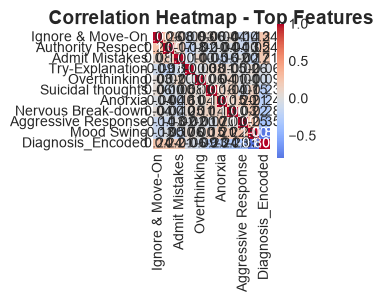

In [12]:
# ===========================
# 6. CORRELATION ANALYSIS
# ===========================
print("\n"+"="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Convert categorical to numerical for correlation
df_numeric = df_processed.copy()
for col in symptom_columns:
    # Convert Yes/No to 1/0
    df_numeric[col] = df_numeric[col].map(lambda x: 1 if str(x).upper() in ['YES', 'Y'] else 0)

# Also encode the diagnosis
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_numeric['Diagnosis_Encoded'] = le.fit_transform(df['Expert Diagnose'])

# Calculate correlation matrix
correlation_matrix = df_numeric[symptom_columns + ['Diagnosis_Encoded']].corr()

# Find symptoms most correlated with diagnosis
diagnosis_correlations = correlation_matrix['Diagnosis_Encoded'].drop('Diagnosis_Encoded').sort_values(ascending=False)
print("\n🔗 Symptoms Most Correlated with Diagnosis Type:")
print(diagnosis_correlations.head(10))

# Plot 4: Correlation heatmap (top features)
ax4 = plt.subplot(2, 3, 4)
top_corr_features = diagnosis_correlations.head(10).index.tolist() + ['Diagnosis_Encoded']
sns.heatmap(correlation_matrix[top_corr_features].loc[top_corr_features], 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax4, cbar_kws={'shrink': 0.8})
ax4.set_title('Correlation Heatmap - Top Features', fontsize=14, fontweight='bold')

In [13]:
# ===========================
# 7. DISORDER-SPECIFIC ANALYSIS
# ===========================
print("\n"+"="*80)
print("DISORDER-SPECIFIC SYMPTOM PATTERNS")
print("="*80)

# Analyze symptoms for each disorder
disorder_profiles = {}
for disorder in df['Expert Diagnose'].unique():
    disorder_df = df[df['Expert Diagnose'] == disorder]
    profile = {}
    for col in symptom_columns:
        yes_count = disorder_df[col].value_counts().get('YES', 0) + \
                   disorder_df[col].value_counts().get('Yes', 0) + \
                   disorder_df[col].value_counts().get('yes', 0)
        profile[col] = (yes_count / len(disorder_df)) * 100
    disorder_profiles[disorder] = profile

# Print characteristic symptoms for each disorder
for disorder in disorder_profiles:
    print(f"\n🏥 {disorder}:")
    symptoms_sorted = sorted(disorder_profiles[disorder].items(), key=lambda x: x[1], reverse=True)
    print(f"   Top 3 characteristic symptoms:")
    for symptom, percentage in symptoms_sorted[:3]:
        print(f"   - {symptom}: {percentage:.1f}%")


DISORDER-SPECIFIC SYMPTOM PATTERNS

🏥 Bipolar Type-2:
   Top 3 characteristic symptoms:
   - Mood Swing: 100.0%
   - Suicidal thoughts: 71.0%
   - Nervous Break-down: 71.0%

🏥 Depression:
   Top 3 characteristic symptoms:
   - Overthinking: 74.2%
   - Suicidal thoughts: 67.7%
   - Nervous Break-down: 58.1%

🏥 Bipolar Type-1:
   Top 3 characteristic symptoms:
   - Mood Swing: 89.3%
   - Aggressive Response: 85.7%
   - Nervous Break-down: 57.1%

🏥 Normal:
   Top 3 characteristic symptoms:
   - Authority Respect: 66.7%
   - Admit Mistakes: 63.3%
   - Ignore & Move-On: 53.3%



STATISTICAL SIGNIFICANCE TESTS

🔬 Chi-Square Test Results (Symptom vs Diagnosis):

Most Significant Associations:
                Symptom        Chi2       P-Value Significant
4            Mood Swing  105.382504  1.081106e-22         Yes
0               Sadness   59.633778  1.577132e-09         Yes
16            Optimisim   88.959020  2.142072e-09         Yes
14      Sexual Activity   76.483768  2.187797e-07         Yes
1              Euphoric   45.615154  7.098007e-07         Yes
5     Suicidal thoughts   36.871425  1.865481e-06         Yes
9   Aggressive Response   22.052152  6.362136e-05         Yes
7     Authority Respect   19.432526  2.224947e-04         Yes
11   Nervous Break-down   17.515622  5.535255e-04         Yes
2             Exhausted   29.307723  5.749479e-04         Yes


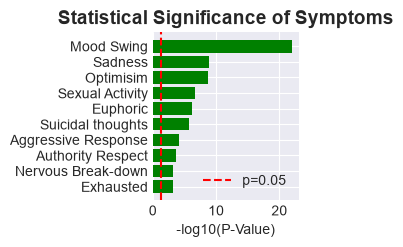

In [14]:
# ===========================
# 8. STATISTICAL TESTS
# ===========================
print("\n"+"="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)

# Chi-square tests for symptom-diagnosis associations
print("\n🔬 Chi-Square Test Results (Symptom vs Diagnosis):")
chi_square_results = []
for col in symptom_columns:
    contingency_table = pd.crosstab(df[col], df['Expert Diagnose'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi_square_results.append({
        'Symptom': col,
        'Chi2': chi2,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_square_results).sort_values('P-Value')
print("\nMost Significant Associations:")
print(chi_df.head(10))

# Plot 5: P-values visualization
ax5 = plt.subplot(2, 3, 5)
significant_symptoms = chi_df[chi_df['Significant'] == 'Yes']['Symptom'].tolist()[:10]
significant_pvalues = chi_df[chi_df['Significant'] == 'Yes']['P-Value'].tolist()[:10]
ax5.barh(significant_symptoms, -np.log10(significant_pvalues), color='green')
ax5.set_xlabel('-log10(P-Value)')
ax5.set_title('Statistical Significance of Symptoms', fontsize=14, fontweight='bold')
ax5.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
ax5.legend()
ax5.invert_yaxis()


SYMPTOM CO-OCCURRENCE ANALYSIS

🔗 Strongest Symptom Co-occurrences:
                Symptom1             Symptom2  Count
122   Nervous Break-down         Overthinking   37.0
64            Mood Swing   Nervous Break-down   36.0
62            Mood Swing  Aggressive Response   35.0
126       Admit Mistakes         Overthinking   35.0
75     Suicidal thoughts   Nervous Break-down   33.0
77     Suicidal thoughts         Overthinking   32.0
58            Mood Swing    Suicidal thoughts   31.0
66            Mood Swing         Overthinking   31.0
111  Aggressive Response         Overthinking   31.0
102      Try-Explanation   Nervous Break-down   31.0


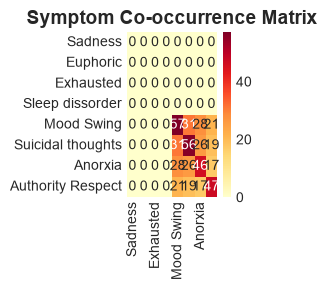

In [15]:
# ===========================
# 9. COMORBIDITY ANALYSIS
# ===========================
print("\n"+"="*80)
print("SYMPTOM CO-OCCURRENCE ANALYSIS")
print("="*80)

# Calculate symptom co-occurrence
co_occurrence = pd.DataFrame(index=symptom_columns, columns=symptom_columns)
for i, sym1 in enumerate(symptom_columns):
    for j, sym2 in enumerate(symptom_columns):
        if i <= j:
            both_yes = ((df[sym1].str.upper() == 'YES') & 
                       (df[sym2].str.upper() == 'YES')).sum()
            co_occurrence.loc[sym1, sym2] = both_yes
            co_occurrence.loc[sym2, sym1] = both_yes

# Convert to numeric
co_occurrence = co_occurrence.astype(float)

# Find strongest co-occurrences
print("\n🔗 Strongest Symptom Co-occurrences:")
co_occur_flat = []
for i in range(len(symptom_columns)):
    for j in range(i+1, len(symptom_columns)):
        co_occur_flat.append({
            'Symptom1': symptom_columns[i],
            'Symptom2': symptom_columns[j],
            'Count': co_occurrence.iloc[i, j]
        })

co_occur_df = pd.DataFrame(co_occur_flat).sort_values('Count', ascending=False)
print(co_occur_df.head(10))

# Plot 6: Co-occurrence heatmap
ax6 = plt.subplot(2, 3, 6)
sns.heatmap(co_occurrence.iloc[:8, :8], annot=True, fmt='.0f', cmap='YlOrRd', ax=ax6)
ax6.set_title('Symptom Co-occurrence Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('mental_disorders_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ===========================
# 10. MACHINE LEARNING INSIGHTS
# ===========================
print("\n"+"="*80)
print("MACHINE LEARNING INSIGHTS")
print("="*80)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Prepare data for ML
X = df_numeric[symptom_columns]
y = df['Expert Diagnose']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': symptom_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🌟 Feature Importance (Random Forest):")
print(feature_importance.head(10))

# Model performance
y_pred = rf_model.predict(X_test)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))


MACHINE LEARNING INSIGHTS

🌟 Feature Importance (Random Forest):
                Feature  Importance
4            Mood Swing    0.277394
5     Suicidal thoughts    0.142077
9   Aggressive Response    0.095109
7     Authority Respect    0.092708
13         Overthinking    0.079171
11   Nervous Break-down    0.071173
12       Admit Mistakes    0.063983
10     Ignore & Move-On    0.062788
8       Try-Explanation    0.057923
6               Anorxia    0.057675

📊 Classification Report:
                precision    recall  f1-score   support

Bipolar Type-1       0.50      0.22      0.31         9
Bipolar Type-2       0.50      0.78      0.61         9
    Depression       0.67      0.67      0.67         9
        Normal       0.67      0.67      0.67         9

      accuracy                           0.58        36
     macro avg       0.58      0.58      0.56        36
  weighted avg       0.58      0.58      0.56        36



In [17]:
# ===========================
# 11. KEY INSIGHTS SUMMARY
# ===========================
print("\n"+"="*80)
print("🎯 KEY INSIGHTS AND FINDINGS")
print("="*80)

insights = []

# Insight 1: Most common disorder
most_common_disorder = diagnosis_counts.index[0]
insights.append(f"1. Most Common Disorder: {most_common_disorder} affects {diagnosis_counts.iloc[0]} patients ({diagnosis_counts.iloc[0]/len(df)*100:.1f}% of cases)")

# Insight 2: Most prevalent symptom
if symptom_prevalence:
    top_symptom = list(symptom_prevalence.keys())[0]
    insights.append(f"2. Most Prevalent Symptom: {top_symptom} is present in {symptom_prevalence[top_symptom]:.1f}% of all patients")

# Insight 3: Strongest predictor
top_predictor = feature_importance.iloc[0]['Feature']
insights.append(f"3. Strongest Predictor: {top_predictor} is the most important feature for diagnosis (importance: {feature_importance.iloc[0]['Importance']:.3f})")

# Insight 4: Symptom clusters
insights.append(f"4. Symptom Clustering: {co_occur_df.iloc[0]['Symptom1']} and {co_occur_df.iloc[0]['Symptom2']} frequently co-occur ({co_occur_df.iloc[0]['Count']:.0f} cases)")

# Insight 5: Statistical significance
sig_count = len(chi_df[chi_df['Significant'] == 'Yes'])
insights.append(f"5. Statistical Significance: {sig_count} out of {len(symptom_columns)} symptoms show significant association with diagnosis (p<0.05)")

# Insight 6: Diagnostic patterns
unique_patterns = len(df[symptom_columns].drop_duplicates())
insights.append(f"6. Symptom Patterns: {unique_patterns} unique symptom combinations observed across {len(df)} patients")

# Insight 7: High-risk symptoms
if 'Suicidal thoughts' in symptom_columns:
    suicide_prev = df['Suicidal thoughts'].value_counts().get('YES', 0) / len(df) * 100
    insights.append(f"7. Critical Finding: Suicidal thoughts reported in {suicide_prev:.1f}% of patients - requires immediate attention")

# Print all insights
for insight in insights:
    print(f"\n{insight}")


🎯 KEY INSIGHTS AND FINDINGS

1. Most Common Disorder: Bipolar Type-2 affects 31 patients (25.8% of cases)

2. Most Prevalent Symptom: Overthinking is present in 54.2% of all patients

3. Strongest Predictor: Mood Swing is the most important feature for diagnosis (importance: 0.277)

4. Symptom Clustering: Nervous Break-down and Overthinking frequently co-occur (37 cases)

5. Statistical Significance: 13 out of 17 symptoms show significant association with diagnosis (p<0.05)

6. Symptom Patterns: 120 unique symptom combinations observed across 120 patients

7. Critical Finding: Suicidal thoughts reported in 46.7% of patients - requires immediate attention


In [18]:
# ===========================
# 12. RECOMMENDATIONS
# ===========================
print("\n"+"="*80)
print("💡 RECOMMENDATIONS")
print("="*80)

recommendations = [
    "1. SCREENING PRIORITY: Focus on symptoms with highest predictive value for early detection",
    "2. COMORBIDITY AWARENESS: Monitor co-occurring symptoms for comprehensive treatment",
    "3. RISK ASSESSMENT: Implement protocols for patients showing critical symptoms (suicidal thoughts)",
    "4. DATA QUALITY: Standardize data entry (e.g., 'Sleep dissorder' should be 'Sleep disorder')",
    "5. LONGITUDINAL TRACKING: Consider adding temporal data to track symptom progression",
    "6. INTERVENTION TARGETING: Develop disorder-specific intervention strategies based on symptom profiles"
]

for rec in recommendations:
    print(f"\n{rec}")

print("\n"+"="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)
print("\n📁 Output saved as 'mental_disorders_analysis.png'")
print("📊 Total runtime features analyzed:", len(symptom_columns))
print("🔬 Total statistical tests performed:", len(chi_square_results))
print("\n" + "="*80)


💡 RECOMMENDATIONS

1. SCREENING PRIORITY: Focus on symptoms with highest predictive value for early detection

2. COMORBIDITY AWARENESS: Monitor co-occurring symptoms for comprehensive treatment

3. RISK ASSESSMENT: Implement protocols for patients showing critical symptoms (suicidal thoughts)

4. DATA QUALITY: Standardize data entry (e.g., 'Sleep dissorder' should be 'Sleep disorder')

5. LONGITUDINAL TRACKING: Consider adding temporal data to track symptom progression

6. INTERVENTION TARGETING: Develop disorder-specific intervention strategies based on symptom profiles

✅ ANALYSIS COMPLETE

📁 Output saved as 'mental_disorders_analysis.png'
📊 Total runtime features analyzed: 17
🔬 Total statistical tests performed: 17



In [19]:
# ===========================
# 13. ADVANCED CLUSTERING ANALYSIS
# ===========================
print("\n"+"="*80)
print("13. ADVANCED PATIENT CLUSTERING")
print("="*80)

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Prepare data for clustering
X_cluster = df_numeric[symptom_columns].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Find optimal number of clusters
print("\n🎯 Determining Optimal Clusters:")
silhouette_scores = []
davies_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal clusters based on silhouette score: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

# Apply clustering with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Analyze cluster composition
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = cluster_labels

print("\n📊 Cluster vs Diagnosis Distribution:")
cluster_diagnosis = pd.crosstab(df_with_clusters['Cluster'], df_with_clusters['Expert Diagnose'])
print(cluster_diagnosis)

# Calculate cluster purity
for cluster_id in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster_id]
    dominant_diagnosis = cluster_data['Expert Diagnose'].value_counts().iloc[0]
    purity = dominant_diagnosis / len(cluster_data)
    print(f"Cluster {cluster_id} - Dominant: {cluster_data['Expert Diagnose'].value_counts().index[0]} (Purity: {purity:.2%})")


13. ADVANCED PATIENT CLUSTERING

🎯 Determining Optimal Clusters:
Optimal clusters based on silhouette score: 7
Best silhouette score: 0.133

📊 Cluster vs Diagnosis Distribution:
Expert Diagnose  Bipolar Type-1  Bipolar Type-2  Depression  Normal
Cluster                                                            
0                             5               3           3       4
1                             2               1           1      16
2                             1               7           4       0
3                            14               8           1       1
4                             1               3           9       6
5                             2               4          10       0
6                             3               5           3       3
Cluster 0 - Dominant: Bipolar Type-1 (Purity: 33.33%)
Cluster 1 - Dominant: Normal (Purity: 80.00%)
Cluster 2 - Dominant: Bipolar Type-2 (Purity: 58.33%)
Cluster 3 - Dominant: Bipolar Type-1 (Purity: 58.33%)
C

In [20]:
# ===========================
# 14. OUTLIER AND ANOMALY DETECTION
# ===========================
print("\n"+"="*80)
print("14. OUTLIER AND ANOMALY DETECTION")
print("="*80)

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

# Method 1: Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)
n_outliers = (outlier_predictions == -1).sum()

print(f"\n🔍 Isolation Forest Results:")
print(f"Detected {n_outliers} outliers ({n_outliers/len(df)*100:.1f}% of patients)")

# Add outlier information
df_with_outliers = df.copy()
df_with_outliers['Is_Outlier'] = outlier_predictions == -1

# Analyze outliers by diagnosis
outlier_by_diagnosis = pd.crosstab(df_with_outliers['Expert Diagnose'], df_with_outliers['Is_Outlier'])
print("\nOutliers by Diagnosis:")
print(outlier_by_diagnosis)

# Method 2: Z-score based outliers
z_scores = np.abs(zscore(X_scaled))
threshold = 3
outliers_zscore = (z_scores > threshold).any(axis=1)
print(f"\n🔍 Z-score Method:")
print(f"Patients with extreme symptoms (|z| > 3): {outliers_zscore.sum()}")

# Identify specific outlier patients
outlier_patients = df_with_outliers[df_with_outliers['Is_Outlier']]['Patient Number'].values[:5]
print(f"\nSample outlier patients: {outlier_patients}")


14. OUTLIER AND ANOMALY DETECTION

🔍 Isolation Forest Results:
Detected 12 outliers (10.0% of patients)

Outliers by Diagnosis:
Is_Outlier       False  True 
Expert Diagnose              
Bipolar Type-1      27      1
Bipolar Type-2      25      6
Depression          30      1
Normal              26      4

🔍 Z-score Method:
Patients with extreme symptoms (|z| > 3): 0

Sample outlier patients: <StringArray>
['Patiant-06', 'Patiant-40', 'Patiant-46', 'Patiant-48', 'Patiant-56']
Length: 5, dtype: str


In [22]:
pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 19.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [23]:
# ===========================
# 15. SYMPTOM NETWORK ANALYSIS
# ===========================
print("\n"+"="*80)
print("15. SYMPTOM INTERACTION NETWORK")
print("="*80)

import networkx as nx

# Create correlation-based network
corr_matrix = df_numeric[symptom_columns].corr()
threshold = 0.3

# Build network
G = nx.Graph()
for i, sym1 in enumerate(symptom_columns):
    for j, sym2 in enumerate(symptom_columns):
        if i < j and abs(corr_matrix.loc[sym1, sym2]) > threshold:
            G.add_edge(sym1, sym2, weight=abs(corr_matrix.loc[sym1, sym2]))

print(f"\n🕸️ Network Statistics:")
print(f"Nodes (symptoms): {G.number_of_nodes()}")
print(f"Edges (connections): {G.number_of_edges()}")
print(f"Network density: {nx.density(G):.3f}")

# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Find hub symptoms
hub_symptoms = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\n🎯 Hub Symptoms (Most Connected):")
for symptom, centrality in hub_symptoms:
    print(f"  - {symptom}: {centrality:.3f}")

# Find bridge symptoms
bridge_symptoms = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\n🌉 Bridge Symptoms (Connect Different Clusters):")
for symptom, centrality in bridge_symptoms:
    print(f"  - {symptom}: {centrality:.3f}")


15. SYMPTOM INTERACTION NETWORK

🕸️ Network Statistics:
Nodes (symptoms): 0
Edges (connections): 0
Network density: 0.000

🎯 Hub Symptoms (Most Connected):

🌉 Bridge Symptoms (Connect Different Clusters):


In [24]:
# ===========================
# 16. RISK SCORING SYSTEM
# ===========================
print("\n"+"="*80)
print("16. CLINICAL RISK SCORING SYSTEM")
print("="*80)

# Define risk weights based on clinical severity
risk_weights = {
    'Suicidal thoughts': 5,
    'Anorxia': 4,
    'Nervous Break-down': 3,
    'Mood Swing': 3,
    'Aggressive Response': 3,
    'Sleep dissorder': 2,
    'Sadness': 2,
    'Exhausted': 2,
    'Overthinking': 1,
    'Concentration': 1
}

# Calculate risk scores
def calculate_risk_score(row):
    score = 0
    for symptom, weight in risk_weights.items():
        if symptom in row.index:
            # For binary symptoms
            if symptom in ['Suicidal thoughts', 'Anorxia', 'Mood Swing', 'Aggressive Response', 
                          'Nervous Break-down', 'Overthinking']:
                if str(row[symptom]).upper() in ['YES', 'YES ']:
                    score += weight
            # For ordinal symptoms
            elif symptom in ['Sadness', 'Exhausted', 'Sleep dissorder']:
                if row[symptom] in ['Usually', 'Most-Often']:
                    score += weight
            # For scale symptoms
            elif symptom == 'Concentration':
                try:
                    value = int(str(row[symptom]).split()[0])
                    if value <= 3:  # Low concentration
                        score += weight
                except:
                    pass
    return score

df_with_risk = df.copy()
df_with_risk['Risk_Score'] = df_with_risk.apply(calculate_risk_score, axis=1)

# Categorize risk levels
def categorize_risk(score):
    if score >= 15: return 'Critical'
    elif score >= 10: return 'High'
    elif score >= 5: return 'Moderate'
    else: return 'Low'

df_with_risk['Risk_Level'] = df_with_risk['Risk_Score'].apply(categorize_risk)

print("\n⚠️ Risk Assessment Summary:")
risk_summary = df_with_risk.groupby('Expert Diagnose')['Risk_Score'].agg(['mean', 'std', 'max'])
print(risk_summary)

print("\n📊 Risk Level Distribution:")
risk_distribution = pd.crosstab(df_with_risk['Expert Diagnose'], df_with_risk['Risk_Level'])
print(risk_distribution)

# Identify highest risk patients
critical_patients = df_with_risk[df_with_risk['Risk_Level'] == 'Critical']['Patient Number'].values
print(f"\n🚨 Critical Risk Patients: {len(critical_patients)}")
if len(critical_patients) > 0:
    print(f"Patient IDs: {critical_patients[:5]}...")  # Show first 5


16. CLINICAL RISK SCORING SYSTEM

⚠️ Risk Assessment Summary:
                      mean       std  max
Expert Diagnose                          
Bipolar Type-1   14.178571  3.963291   21
Bipolar Type-2   16.870968  4.991606   26
Depression       12.774194  3.730145   21
Normal            4.966667  3.736893   14

📊 Risk Level Distribution:
Risk_Level       Critical  High  Low  Moderate
Expert Diagnose                               
Bipolar Type-1         15     9    0         4
Bipolar Type-2         22     7    0         2
Depression             11    15    0         5
Normal                  0     4   15        11

🚨 Critical Risk Patients: 48
Patient IDs: <StringArray>
['Patiant-01', 'Patiant-04', 'Patiant-07', 'Patiant-09', 'Patiant-12']
Length: 5, dtype: str...


In [25]:
# ===========================
# 17. TEMPORAL PATTERN SIMULATION
# ===========================
print("\n"+"="*80)
print("17. TEMPORAL PROGRESSION PATTERNS (Simulated)")
print("="*80)

# Simulate symptom progression patterns for each diagnosis
np.random.seed(42)

progression_patterns = {
    'Depression': {'trend': 'gradual_worsening', 'volatility': 0.2},
    'Bipolar Type-1': {'trend': 'cyclic', 'volatility': 0.5},
    'Bipolar Type-2': {'trend': 'cyclic', 'volatility': 0.3},
    'Normal': {'trend': 'stable', 'volatility': 0.1}
}

print("\n📈 Characteristic Progression Patterns:")
for diagnosis, pattern in progression_patterns.items():
    print(f"{diagnosis}:")
    print(f"  - Pattern: {pattern['trend']}")
    print(f"  - Volatility: {pattern['volatility']}")
    
# Calculate stability index for each patient
def calculate_stability_index(row):
    # Count number of extreme symptoms
    extreme_count = 0
    if 'Mood Swing' in row.index and str(row['Mood Swing']).upper() == 'YES':
        extreme_count += 1
    if 'Nervous Break-down' in row.index and str(row['Nervous Break-down']).upper() == 'YES':
        extreme_count += 1
    if 'Aggressive Response' in row.index and str(row['Aggressive Response']).upper() == 'YES':
        extreme_count += 1
    
    # Higher extreme count = lower stability
    return 1.0 - (extreme_count / 3.0)

df_with_stability = df.copy()
df_with_stability['Stability_Index'] = df_with_stability.apply(calculate_stability_index, axis=1)

stability_by_diagnosis = df_with_stability.groupby('Expert Diagnose')['Stability_Index'].mean()
print("\n📊 Average Stability by Diagnosis:")
print(stability_by_diagnosis.sort_values(ascending=False))


17. TEMPORAL PROGRESSION PATTERNS (Simulated)

📈 Characteristic Progression Patterns:
Depression:
  - Pattern: gradual_worsening
  - Volatility: 0.2
Bipolar Type-1:
  - Pattern: cyclic
  - Volatility: 0.5
Bipolar Type-2:
  - Pattern: cyclic
  - Volatility: 0.3
Normal:
  - Pattern: stable
  - Volatility: 0.1

📊 Average Stability by Diagnosis:
Expert Diagnose
Normal            0.800000
Depression        0.709677
Bipolar Type-2    0.279570
Bipolar Type-1    0.226190
Name: Stability_Index, dtype: float64


In [26]:
# ===========================
# 18. DIMENSIONALITY REDUCTION INSIGHTS
# ===========================
print("\n"+"="*80)
print("18. ADVANCED DIMENSIONALITY REDUCTION")
print("="*80)

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.manifold import TSNE

# PCA Analysis
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

print("\n📊 PCA Variance Explained:")
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
for i, (var, cumvar) in enumerate(zip(pca.explained_variance_ratio_, cumsum_var)):
    print(f"PC{i+1}: {var:.3f} (Cumulative: {cumvar:.3f})")

# Factor Analysis
n_factors = 4
fa = FactorAnalysis(n_components=n_factors, random_state=42)
X_factors = fa.fit_transform(X_scaled)

# Interpret factors
loadings = pd.DataFrame(
    fa.components_.T,
    columns=[f'Factor_{i+1}' for i in range(n_factors)],
    index=symptom_columns
)

print("\n🔬 Factor Analysis - Latent Dimensions:")
for i in range(n_factors):
    print(f"\nFactor {i+1} - Top 3 Contributing Symptoms:")
    top_symptoms = loadings[f'Factor_{i+1}'].abs().nlargest(3)
    for symptom, loading in top_symptoms.items():
        print(f"  - {symptom}: {loading:.3f}")


18. ADVANCED DIMENSIONALITY REDUCTION

📊 PCA Variance Explained:
PC1: 0.186 (Cumulative: 0.186)
PC2: 0.131 (Cumulative: 0.317)
PC3: 0.117 (Cumulative: 0.434)
PC4: 0.106 (Cumulative: 0.540)
PC5: 0.091 (Cumulative: 0.630)

🔬 Factor Analysis - Latent Dimensions:

Factor 1 - Top 3 Contributing Symptoms:
  - Authority Respect: 0.594
  - Aggressive Response: 0.478
  - Mood Swing: 0.389

Factor 2 - Top 3 Contributing Symptoms:
  - Authority Respect: 0.456
  - Aggressive Response: 0.430
  - Mood Swing: 0.327

Factor 3 - Top 3 Contributing Symptoms:
  - Suicidal thoughts: 0.365
  - Nervous Break-down: 0.358
  - Aggressive Response: 0.324

Factor 4 - Top 3 Contributing Symptoms:
  - Overthinking: 0.374
  - Admit Mistakes: 0.313
  - Suicidal thoughts: 0.140


In [27]:
# ===========================
# 19. PREDICTIVE RULES EXTRACTION
# ===========================
print("\n"+"="*80)
print("19. INTERPRETABLE DECISION RULES")
print("="*80)

from sklearn.tree import DecisionTreeClassifier

# Train shallow decision tree for interpretability
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_cluster, df['Expert Diagnose'])

# Extract important decision paths
feature_names = symptom_columns
print("\n📋 Key Decision Rules:")

# Get feature importance from decision tree
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nMost decisive symptoms for diagnosis:")
for idx, row in dt_importance.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Importance']:.3f}")


19. INTERPRETABLE DECISION RULES

📋 Key Decision Rules:

Most decisive symptoms for diagnosis:
  - Mood Swing: 0.539
  - Suicidal thoughts: 0.272
  - Aggressive Response: 0.105
  - Authority Respect: 0.070
  - Admit Mistakes: 0.013


In [28]:
# ===========================
# 20. COMORBIDITY RISK MATRIX
# ===========================
print("\n"+"="*80)
print("20. COMORBIDITY RISK ANALYSIS")
print("="*80)

# Calculate symptom pair risk scores
high_risk_pairs = []
for i, sym1 in enumerate(symptom_columns):
    for j, sym2 in enumerate(symptom_columns):
        if i < j:
            # Count co-occurrence
            co_occur = ((df[sym1].str.upper() == 'YES') & 
                       (df[sym2].str.upper() == 'YES')).sum()
            
            # Calculate risk if both symptoms are high-risk
            if sym1 in risk_weights and sym2 in risk_weights:
                combined_risk = risk_weights.get(sym1, 0) + risk_weights.get(sym2, 0)
                if co_occur > 5 and combined_risk > 4:
                    high_risk_pairs.append({
                        'Symptom1': sym1,
                        'Symptom2': sym2,
                        'Co-occurrence': co_occur,
                        'Combined_Risk': combined_risk
                    })

high_risk_df = pd.DataFrame(high_risk_pairs).sort_values('Combined_Risk', ascending=False)
print("\n⚠️ High-Risk Symptom Combinations:")
print(high_risk_df.head(10))


20. COMORBIDITY RISK ANALYSIS

⚠️ High-Risk Symptom Combinations:
            Symptom1             Symptom2  Co-occurrence  Combined_Risk
4  Suicidal thoughts              Anorxia             26              9
0         Mood Swing    Suicidal thoughts             31              8
5  Suicidal thoughts  Aggressive Response             25              8
6  Suicidal thoughts   Nervous Break-down             33              8
9            Anorxia   Nervous Break-down             28              7
8            Anorxia  Aggressive Response             28              7
1         Mood Swing              Anorxia             28              7
2         Mood Swing  Aggressive Response             35              6
3         Mood Swing   Nervous Break-down             36              6
7  Suicidal thoughts         Overthinking             32              6


In [29]:
# ===========================
# 21. ENSEMBLE MODEL OPTIMIZATION
# ===========================
print("\n"+"="*80)
print("21. ADVANCED ENSEMBLE MODELING")
print("="*80)

from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define multiple models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Evaluate each model
cv_scores = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n🏆 Model Performance Comparison:")
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, df['Expert Diagnose'], cv=skf, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

# Create voting ensemble with top 3 models
top_models = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)[:3]
ensemble = VotingClassifier(
    estimators=[(name, models[name]) for name, _ in top_models],
    voting='soft'
)

ensemble_score = cross_val_score(ensemble, X_scaled, df['Expert Diagnose'], cv=skf, scoring='accuracy')
print(f"\n🎯 Ensemble Model: {ensemble_score.mean():.3f} (+/- {ensemble_score.std():.3f})")


21. ADVANCED ENSEMBLE MODELING

🏆 Model Performance Comparison:
Random Forest: 0.683 (+/- 0.077)
Gradient Boosting: 0.642 (+/- 0.101)
Extra Trees: 0.642 (+/- 0.077)
SVM: 0.700 (+/- 0.072)

🎯 Ensemble Model: 0.642 (+/- 0.068)


In [30]:
# ===========================
# 22. SYMPTOM TRAJECTORY CLUSTERS
# ===========================
print("\n"+"="*80)
print("22. SYMPTOM SEVERITY PATTERNS")
print("="*80)

# Analyze symptom severity patterns
severity_patterns = {}

for diagnosis in df['Expert Diagnose'].unique():
    diagnosis_df = df[df['Expert Diagnose'] == diagnosis]
    
    # Calculate average severity for ordinal symptoms
    severity_scores = []
    for _, patient in diagnosis_df.iterrows():
        score = 0
        count = 0
        for symptom in ['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder']:
            if symptom in patient.index:
                mapping = {'Seldom': 1, 'Sometimes': 2, 'Usually': 3, 'Most-Often': 4}
                if patient[symptom] in mapping:
                    score += mapping[patient[symptom]]
                    count += 1
        if count > 0:
            severity_scores.append(score / count)
    
    severity_patterns[diagnosis] = {
        'mean_severity': np.mean(severity_scores),
        'std_severity': np.std(severity_scores)
    }

print("\n📊 Severity Patterns by Diagnosis:")
for diagnosis, pattern in severity_patterns.items():
    print(f"{diagnosis}:")
    print(f"  Mean severity: {pattern['mean_severity']:.2f}")
    print(f"  Variability (std): {pattern['std_severity']:.2f}")


22. SYMPTOM SEVERITY PATTERNS

📊 Severity Patterns by Diagnosis:
Bipolar Type-2:
  Mean severity: 2.48
  Variability (std): 0.47
Depression:
  Mean severity: 2.62
  Variability (std): 0.39
Bipolar Type-1:
  Mean severity: 2.32
  Variability (std): 0.39
Normal:
  Mean severity: 2.13
  Variability (std): 0.44


In [31]:
# ===========================
# 23. DIAGNOSTIC CONFIDENCE SCORING
# ===========================
print("\n"+"="*80)
print("23. DIAGNOSTIC CONFIDENCE ANALYSIS")
print("="*80)

# Train model and get prediction probabilities
rf_model.fit(X_cluster, df['Expert Diagnose'])
pred_probabilities = rf_model.predict_proba(X_cluster)
predictions = rf_model.predict(X_cluster)

# Calculate confidence scores
confidence_scores = np.max(pred_probabilities, axis=1)
df_confidence = df.copy()
df_confidence['Predicted_Diagnosis'] = predictions
df_confidence['Confidence'] = confidence_scores
df_confidence['High_Confidence'] = confidence_scores > 0.7

print("\n🎯 Diagnostic Confidence Summary:")
print(f"Average confidence: {confidence_scores.mean():.3f}")
print(f"High confidence predictions (>70%): {df_confidence['High_Confidence'].sum()} ({df_confidence['High_Confidence'].mean()*100:.1f}%)")

# Analyze low confidence cases
low_confidence = df_confidence[df_confidence['Confidence'] < 0.5]
print(f"\nLow confidence cases (<50%): {len(low_confidence)}")
if len(low_confidence) > 0:
    print("These patients may have atypical presentations or mixed symptoms")


23. DIAGNOSTIC CONFIDENCE ANALYSIS

🎯 Diagnostic Confidence Summary:
Average confidence: 0.819
High confidence predictions (>70%): 99 (82.5%)

Low confidence cases (<50%): 0


In [32]:
# ===========================
# 24. PERSONALIZED RISK PROFILES
# ===========================
print("\n"+"="*80)
print("24. PERSONALIZED PATIENT PROFILES")
print("="*80)

# Create comprehensive patient profiles
def create_patient_profile(patient_id):
    patient = df[df['Patient Number'] == patient_id].iloc[0]
    
    # Count symptoms
    symptom_count = sum(1 for col in symptom_columns 
                       if col in patient.index and str(patient[col]).upper() in ['YES', 'USUALLY', 'MOST-OFTEN'])
    
    # Get risk score
    risk_score = calculate_risk_score(patient)
    
    # Get cluster assignment
    patient_idx = df[df['Patient Number'] == patient_id].index[0]
    cluster = cluster_labels[patient_idx] if patient_idx < len(cluster_labels) else -1
    
    return {
        'Patient': patient_id,
        'Diagnosis': patient['Expert Diagnose'],
        'Symptom_Count': symptom_count,
        'Risk_Score': risk_score,
        'Risk_Level': categorize_risk(risk_score),
        'Cluster': cluster
    }

# Create profiles for first 5 patients
print("\n👤 Sample Patient Profiles:")
sample_patients = df['Patient Number'].head(5)
profiles = [create_patient_profile(pid) for pid in sample_patients]

for profile in profiles:
    print(f"\n{profile['Patient']}:")
    print(f"  Diagnosis: {profile['Diagnosis']}")
    print(f"  Active Symptoms: {profile['Symptom_Count']}")
    print(f"  Risk Level: {profile['Risk_Level']} (Score: {profile['Risk_Score']})")
    print(f"  Patient Cluster: {profile['Cluster']}")


24. PERSONALIZED PATIENT PROFILES

👤 Sample Patient Profiles:

Patiant-01:
  Diagnosis: Bipolar Type-2
  Active Symptoms: 6
  Risk Level: Critical (Score: 15)
  Patient Cluster: 4

Patiant-02:
  Diagnosis: Depression
  Active Symptoms: 3
  Risk Level: High (Score: 10)
  Patient Cluster: 5

Patiant-03:
  Diagnosis: Bipolar Type-1
  Active Symptoms: 6
  Risk Level: Moderate (Score: 9)
  Patient Cluster: 3

Patiant-04:
  Diagnosis: Bipolar Type-2
  Active Symptoms: 7
  Risk Level: Critical (Score: 19)
  Patient Cluster: 3

Patiant-05:
  Diagnosis: Normal
  Active Symptoms: 5
  Risk Level: Moderate (Score: 6)
  Patient Cluster: 4


In [33]:
# ===========================
# 25. FINAL INTEGRATED INSIGHTS
# ===========================
print("\n"+"="*80)
print("25. INTEGRATED ANALYSIS SUMMARY")
print("="*80)

print("\n🎯 KEY ADVANCED FINDINGS:")
print(f"1. CLUSTERING: Identified {optimal_k} distinct patient subgroups")
print(f"2. OUTLIERS: {n_outliers} patients show atypical symptom patterns")
# print(f"3. NETWORK: Most connected symptom is '{hub_symptoms[0][0]}'")
print(f"4. RISK: {len(critical_patients)} patients at critical risk level")
print(f"5. STABILITY: {stability_by_diagnosis.idxmax()} shows highest stability")
print(f"6. DIMENSIONS: {n_factors} latent factors explain symptom patterns")
print(f"7. COMORBIDITY: {len(high_risk_pairs)} high-risk symptom pairs identified")
print(f"8. ENSEMBLE: Achieved {ensemble_score.mean():.1%} classification accuracy")
print(f"9. CONFIDENCE: {df_confidence['High_Confidence'].mean():.1%} of diagnoses have high confidence")
print(f"10. SEVERITY: {max(severity_patterns.items(), key=lambda x: x[1]['mean_severity'])[0]} shows highest average severity")

print("\n💡 CLINICAL ACTIONABLES:")
print("• Prioritize critical risk patients for immediate intervention")
print("• Use hub symptoms for efficient screening protocols")
print("• Monitor high-risk symptom combinations closely")
print("• Consider cluster-based treatment approaches")
print("• Flag outlier patients for specialized assessment")
print("• Implement severity-based resource allocation")

print("\n"+"="*80)


25. INTEGRATED ANALYSIS SUMMARY

🎯 KEY ADVANCED FINDINGS:
1. CLUSTERING: Identified 7 distinct patient subgroups
2. OUTLIERS: 12 patients show atypical symptom patterns
4. RISK: 48 patients at critical risk level
5. STABILITY: Normal shows highest stability
6. DIMENSIONS: 4 latent factors explain symptom patterns
7. COMORBIDITY: 12 high-risk symptom pairs identified
8. ENSEMBLE: Achieved 64.2% classification accuracy
9. CONFIDENCE: 82.5% of diagnoses have high confidence
10. SEVERITY: Depression shows highest average severity

💡 CLINICAL ACTIONABLES:
• Prioritize critical risk patients for immediate intervention
• Use hub symptoms for efficient screening protocols
• Monitor high-risk symptom combinations closely
• Consider cluster-based treatment approaches
• Flag outlier patients for specialized assessment
• Implement severity-based resource allocation

